# Imputation experiments (RQ1/RQ2)
**Run order:** `tuning.ipynb` → `imputation.ipynb` → `downstream.ipynb`

Masks the target beam columns under each missingness mechanism (MCAR, MAR, MNAR, MCAR-Row) at three rates (10 %, 30 %, 50 %), runs all seven imputers with parameters frozen in `results/tuned_params.json`, and records reconstruction error (RMSE, MAE) and distributional fidelity metrics (Wasserstein-1, variance retention, mean shift, correlation distortion) per run.

Results are appended to `results/csv/{dataset}_imputation_results.csv` with resume-caching keyed on `(scenario, proportion, method, seed)`, so interrupted runs can be restarted without re-computing completed cells.

**To switch datasets:** change `DATASET` in Cell 1 to `"scenario5"` or `"scenario33"` and re-run.

## 1. Path setup + dataset

In [11]:
# ---------------------------------------------------------------------------
# Path setup + dataset switch. This is the ONLY cell you change between
# datasets: set DATASET to a key registered in common.datasets.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

DATASET = "scenario5"          # "scenario5" | "scenario33"


def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    return start.parent


REPO_ROOT   = _find_repo_root(Path.cwd())
SRC         = REPO_ROOT / "src"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
TUNED_PARAMS_PATH = RESULTS_DIR / "tuned_params.json"
for _d in (FIGURES_DIR, CSV_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_diffputer = REPO_ROOT / "external" / "DiffPuter"
for _p in (REPO_ROOT, SRC,
           _diffputer / "baselines" / "GRAPE",
           _diffputer / "baselines",
           _diffputer):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

from common.datasets import get_dataset

spec = get_dataset(DATASET)
DATA_DIR = REPO_ROOT / "data" / spec.data_dirname
print(f"Dataset: {spec.name}")

print("DATA_DIR:", DATA_DIR)

Dataset: scenario5
DATA_DIR: /mnt/c/Users/Kenneth Chan/Documents/School/Research Project/Repo/ImputationFor6GDatasets/data/Scenario5


In [12]:
# Check environment and imports
from common.environment import check_environment
check_environment()
# Enable automatic reloading of edited modules in this notebook
%load_ext autoreload
%autoreload 2

Required packages
------------------------------------------------------------
  ✓ numpy              OK       1.26.4
  ✓ pandas             OK       2.3.3
  ✓ scipy              OK       1.17.1
  ✓ scikit-learn       OK       1.6.1
  ✓ matplotlib         OK       3.10.9
  ✓ statsmodels        OK       0.14.6
  ✓ fancyimpute        OK       0.7.0
  ✓ hyperimpute        OK       0.1.17
  ✓ torch              OK       2.4.1
  ✓ torch_geometric    OK       2.7.0
  ✓ h5py               OK       3.14.0
  ✓ networkx           OK       3.6.1
  ✓ POT                OK       0.9.6.post1
  ✓ FrEIA              OK       0.2
  ✓ timm               OK       1.0.27
  ✓ PyYAML             OK       6.0.3
  ✓ ipykernel          OK       7.2.0

Optional packages
------------------------------------------------------------
  ✓ torch_scatter      OK       2.1.2+pt24cu121

Smoke-test imports for imputation APIs
------------------------------------------------------------
  ✓ Mean / kNN (sklearn): OK
  ✓ MI

## 2. Dataset analysis (raw)

Reads the raw CSV before any cleaning or column drops. Purely informational: shows the full column list and per-column missing-value counts so you can verify the loader's drop list is correct. Does not affect downstream cells.

In [13]:
import pandas as pd
import numpy as np

# Raw CSV exploration (pre-cleaning), purely informational.
df = pd.read_csv(DATA_DIR / spec.raw_csv_name)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (2300, 15)

Columns: ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit1_beam_index', 'seq_index', 'time_stamp[UTC]', 'unit2_direction', 'unit2_num_sat', 'unit2_sat_used', 'unit2_fix_type', 'unit2_DGPS', 'unit2_PDOP', 'unit2_HDOP']

Missing values:
index               0
unit1_rgb           0
unit1_pwr_60ghz     0
unit1_loc           0
unit2_loc           0
unit1_beam_index    0
seq_index           0
time_stamp[UTC]     0
unit2_direction     0
unit2_num_sat       0
unit2_sat_used      0
unit2_fix_type      0
unit2_DGPS          0
unit2_PDOP          0
unit2_HDOP          0
dtype: int64


,index,unit1_rgb,unit1_pwr_60ghz,unit1_loc,unit2_loc,unit1_beam_index,seq_index,time_stamp[UTC],unit2_direction,unit2_num_sat,unit2_sat_used,unit2_fix_type,unit2_DGPS,unit2_PDOP,unit2_HDOP
0,1,./unit1/camera_data/image_BS1_259_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_0.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_0.txt,60,1,['03-20-31-142'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
1,2,./unit1/camera_data/image_BS1_260_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_1.txt,60,1,['03-20-31-284'],1,24,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
2,3,./unit1/camera_data/image_BS1_261_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_2.txt,58,1,['03-20-31-426'],1,14,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
3,4,./unit1/camera_data/image_BS1_262_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_3.txt,59,1,['03-20-31-568'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
4,5,./unit1/camera_data/image_BS1_263_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_4.txt,60,1,['03-20-31-710'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6


## 3. Load clean data

Calls `spec.loader`, which parses the raw CSV, drops non-feature columns, resolves the beam label, and returns a fully observed DataFrame. Any rows with parse failures are flagged; `ExperimentConfig.validate` will raise if NaNs remain in the retained columns.

In [14]:
clean_data = spec.loader(DATA_DIR)
clean_data.head()

Parsing location files...
Parsing mmWave power files...
Argmax matches unit1_beam_index: 100.00%
Parsed shape: (2300, 71)  |  missing cells: 0
Dropped 0 incomplete row(s) (2300 -> 2300); experiments require fully observed input.
Clean data shape: (2300, 71)


,beam_00,beam_01,beam_02,beam_03,beam_04,beam_05,beam_06,beam_07,beam_08,beam_09,...,beam_61,beam_62,beam_63,seq_index,unit2_direction,unit2_num_sat,unit2_PDOP,unit2_HDOP,unit2_lat,unit2_lon
0,0.055968,0.070338,0.066935,0.069162,0.066099,0.072669,0.069387,0.072276,0.077617,0.080167,...,0.210889,0.141087,0.057206,1,1,21,1.1,0.6,33.420483,-111.928924
1,0.056760,0.070169,0.066501,0.066432,0.064224,0.067116,0.067262,0.069973,0.072604,0.073346,...,0.119123,0.104426,0.054459,1,1,24,1.1,0.6,33.420488,-111.928924
2,0.055729,0.070609,0.067872,0.066260,0.066733,0.070419,0.072179,0.075715,0.081830,0.080061,...,0.147073,0.119795,0.056269,1,1,14,1.1,0.6,33.420492,-111.928924
3,0.056817,0.065785,0.065563,0.065042,0.065913,0.067290,0.066408,0.066978,0.070079,0.068478,...,0.150416,0.099099,0.055611,1,1,21,1.1,0.6,33.420497,-111.928925
4,0.051511,0.068646,0.067928,0.066194,0.066387,0.072280,0.071292,0.072404,0.073234,0.070456,...,0.091702,0.082473,0.055077,1,1,21,1.1,0.6,33.420502,-111.928925


## 4. Experiment configuration

Builds `ExperimentConfig` from the dataset spec. The target columns (beam power columns) are the only ones amputed; GPS columns ride along as observed predictors and are never masked. Three seeds per cell for cheap methods; DiffPuter and GRAPE use one seed, controlled via the per-imputer fold count in Cell 12.

In [15]:
from imputers.imputers import (
    MeanImputer, KNNImputerWrapper, MICEImputer,
    SoftImputeWrapper, HyperImputeImputer,
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer

from common.experiment import ExperimentConfig, run_experiments

In [16]:
# ---------------------------------------------------------------------------
# Configuration — built from the dataset spec.
# ---------------------------------------------------------------------------
cfg = ExperimentConfig(
    target_cols=spec.target_cols,
    retained_cols=spec.retained_cols,
    mar_driver_cols=spec.mar_driver_cols,
    mar_score_mode=spec.mar_score_mode,
    proportions=[0.10, 0.30, 0.50],
    n_seeds=3,
)

## 5. Run experiments

Loads frozen hyperparameters from `tuned_params.json` and runs the full `(mechanism × proportion × method × seed)` grid. Each completed run is appended to the results CSV immediately, so the notebook can be interrupted and resumed. The `scenario_filter` list controls which mechanisms are included; remove entries to run a subset.

In [17]:
from common.tuning import load_tuned_params

# Load the SAME tuned params used downstream so the two tables stay comparable.
# Index keys directly and assert presence: a missing tuned value should fail
# loudly, not silently fall back to a library default.
tp = load_tuned_params(TUNED_PARAMS_PATH, spec.name)
assert tp, (f"No tuned params for '{spec.name}' in {TUNED_PARAMS_PATH}. "
            f"Run tuning.ipynb with DATASET='{spec.name}' first.")
for _k in ("knn_n_neighbors", "softimpute_shrinkage", "diffputer",
           "grape_epochs", "grape_node_edge_dim", "grape_lr"):
    assert _k in tp, f"tuned_params.json missing key '{_k}' for {spec.name}."
print("Loaded tuned params:",
      {k: ("{...}" if isinstance(v, dict) else v) for k, v in tp.items()})

mean        = MeanImputer()
knn         = KNNImputerWrapper(k=tp["knn_n_neighbors"])
mice        = MICEImputer()
softimpute  = SoftImputeWrapper(shrinkage_value=tp["softimpute_shrinkage"])
hyperimpute = HyperImputeImputer()
diffputer   = DiffPuterImputer(**tp["diffputer"])
grape       = GRAPEImputer(epochs=tp["grape_epochs"],
                           node_dim=tp["grape_node_edge_dim"],
                           edge_dim=tp["grape_node_edge_dim"],
                           lr=tp["grape_lr"])

imputers = [mean, knn, mice, softimpute, hyperimpute, diffputer, grape]

Loaded tuned params: {'knn_n_neighbors': 5, 'softimpute_shrinkage': None, 'grape_epochs': 20000, 'grape_node_edge_dim': 128, 'grape_lr': 0.000904395708283654, 'diffputer': '{...}'}


In [18]:
RECON_CSV = CSV_DIR / f"{spec.name}_imputation_results.csv"
scenario_filter = ["MCAR", "MAR", "MNAR", "MCAR-Row"]
results_df, summary_df = run_experiments(
    clean_data, config=cfg, imputers=imputers,
    scenario_filter=scenario_filter, verbose=True,
    results_csv=RECON_CSV,
)
display(summary_df)

Filtered to 4 scenario(s): ['MCAR', 'MAR', 'MNAR', 'MCAR-Row']
Resuming: 252 run(s) already in scenario5_imputation_results.csv.
Total runs: 252 (4 scenarios x 3 props x 7 methods x 3 seeds)
  [3/252] MCAR | p=0.1 | Mean: cached, skipped 3 seed(s)
  [6/252] MCAR | p=0.1 | kNN: cached, skipped 3 seed(s)
  [9/252] MCAR | p=0.1 | MICE: cached, skipped 3 seed(s)
  [12/252] MCAR | p=0.1 | SoftImpute: cached, skipped 3 seed(s)
  [15/252] MCAR | p=0.1 | HyperImpute: cached, skipped 3 seed(s)
  [18/252] MCAR | p=0.1 | DiffPuter: cached, skipped 3 seed(s)
  [21/252] MCAR | p=0.1 | GRAPE: cached, skipped 3 seed(s)
  [24/252] MCAR | p=0.3 | Mean: cached, skipped 3 seed(s)
  [27/252] MCAR | p=0.3 | kNN: cached, skipped 3 seed(s)
  [30/252] MCAR | p=0.3 | MICE: cached, skipped 3 seed(s)
  [33/252] MCAR | p=0.3 | SoftImpute: cached, skipped 3 seed(s)
  [36/252] MCAR | p=0.3 | HyperImpute: cached, skipped 3 seed(s)
  [39/252] MCAR | p=0.3 | DiffPuter: cached, skipped 3 seed(s)
  [42/252] MCAR | p=0.3

,scenario,proportion,method,rmse_seedmean,rmse_seedstd,mae_seedmean,mae_seedstd,wasserstein_mean_seedmean,wasserstein_mean_seedstd,wasserstein_std_seedmean,...,mean_shift_std_seedmean,mean_shift_std_seedstd,variance_retention_mean_seedmean,variance_retention_mean_seedstd,variance_retention_std_seedmean,variance_retention_std_seedstd,corr_frob_seedmean,corr_frob_seedstd,avg_masked_cells,n_seeds
0,MCAR,0.1,Mean,1.0114,0.0190,0.6339,0.0070,0.6342,0.0072,0.0466,...,0.0419,0.0060,0.0000,0.0000,0.0000,0.0000,2.0177,0.0717,14741.0,3
1,MCAR,0.1,kNN,0.2459,0.0074,0.1313,0.0029,0.0533,0.0013,0.0225,...,0.0139,0.0003,0.8618,0.0023,0.0789,0.0093,0.1783,0.0078,14741.0,3
2,MCAR,0.1,MICE,0.1733,0.0024,0.0937,0.0013,0.0351,0.0002,0.0239,...,0.0066,0.0007,0.9711,0.0036,0.0758,0.0045,0.1378,0.0039,14741.0,3
3,MCAR,0.1,SoftImpute,0.2043,0.0039,0.1102,0.0016,0.0653,0.0013,0.0456,...,0.0079,0.0008,0.8222,0.0037,0.1141,0.0024,0.1808,0.0142,14741.0,3
4,MCAR,0.1,HyperImpute,0.1741,0.0019,0.0936,0.0012,0.0344,0.0002,0.0217,...,0.0064,0.0007,0.9693,0.0028,0.0718,0.0035,0.1373,0.0054,14741.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,MCAR-Row,0.5,MICE,0.9935,0.0103,0.6181,0.0010,0.6034,0.0011,0.0372,...,0.0305,0.0082,0.0046,0.0004,0.0197,0.0030,1.6670,0.0157,73600.0,3
80,MCAR-Row,0.5,SoftImpute,0.9717,0.0104,0.6000,0.0037,0.5788,0.0032,0.0307,...,0.0152,0.0041,0.0090,0.0002,0.0083,0.0002,1.2767,0.0451,73600.0,3
81,MCAR-Row,0.5,HyperImpute,0.9962,0.0150,0.6207,0.0046,0.6060,0.0061,0.0406,...,0.0304,0.0084,0.0049,0.0015,0.0239,0.0034,1.7249,0.0498,73600.0,3
82,MCAR-Row,0.5,DiffPuter,1.0376,0.0114,0.4954,0.0097,0.3989,0.0100,0.0431,...,0.0528,0.0013,0.0829,0.0242,0.0662,0.0220,3.5793,0.3192,73600.0,3


## 6. Visualise and persist

Reads the results CSV back from disk (making plots reproducible independently of the run cell) and produces:

- Per-mechanism RMSE/MAE bar charts saved to `results/figures/`
- 2×2 mechanism-grid figures with `sharey='row'` (scale differences   disclosed in captions)
- LaTeX fidelity summary tables (Wasserstein, variance retention, mean shift,   correlation distortion) for the appendix
- Cross-dataset RMSE comparison figure combining both scenarios

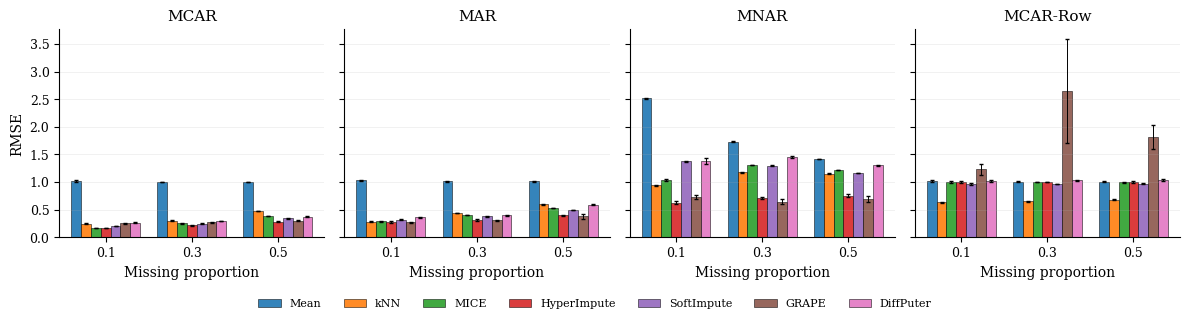

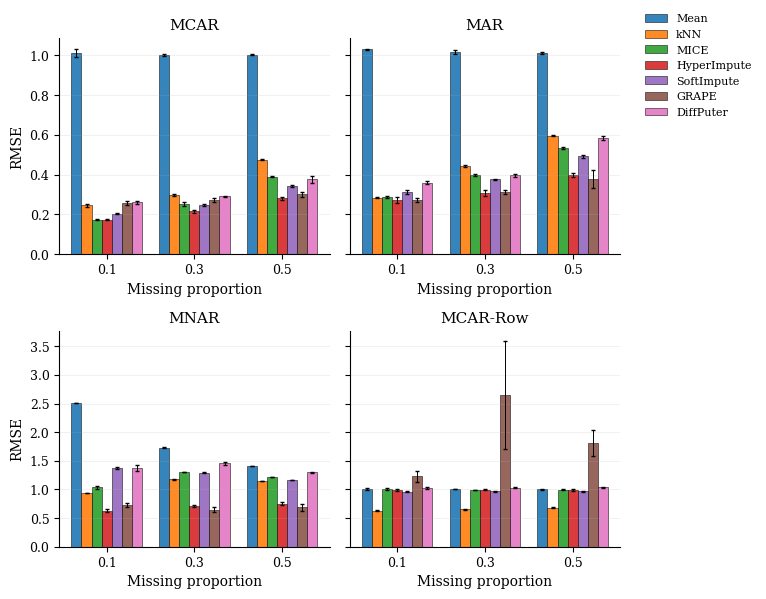

'\\begin{tabular}{lcccc}\n\\toprule\n & Wasserstein & Mean shift & Var.\\ retention & Corr.\\ Frob. \\\\\nMethod &  &  &  &  \\\\\n\\midrule\nMean & 0.630 $\\pm$ 0.001 & 0.036 $\\pm$ 0.002 & 0.000 $\\pm$ 0.000 & 5.819 $\\pm$ 0.016 \\\\\nkNN & 0.053 $\\pm$ 0.000 & 0.030 $\\pm$ 0.001 & 0.814 $\\pm$ 0.003 & 0.512 $\\pm$ 0.029 \\\\\nMICE & 0.048 $\\pm$ 0.001 & 0.008 $\\pm$ 0.001 & 0.896 $\\pm$ 0.009 & 0.355 $\\pm$ 0.016 \\\\\nHyperImpute & \\textbf{0.031 $\\pm$ 0.001} & 0.008 $\\pm$ 0.001 & \\textbf{0.945 $\\pm$ 0.008} & \\textbf{0.336 $\\pm$ 0.017} \\\\\nSoftImpute & 0.077 $\\pm$ 0.001 & \\textbf{0.006 $\\pm$ 0.001} & 0.769 $\\pm$ 0.003 & 0.556 $\\pm$ 0.049 \\\\\nGRAPE & 0.087 $\\pm$ 0.022 & 0.053 $\\pm$ 0.030 & 0.900 $\\pm$ 0.013 & 0.892 $\\pm$ 0.047 \\\\\nDiffPuter & 0.054 $\\pm$ 0.005 & 0.028 $\\pm$ 0.009 & 1.070 $\\pm$ 0.006 & 0.592 $\\pm$ 0.020 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [19]:
from common.visualization import plot_metric_bars, err_table, stat_fidelity_table, plot_2x2_grid

RECON_CSV = CSV_DIR / f"{spec.name}_imputation_results.csv"

# Persist this run, then read back from CSV so plots/tables are reproducible
# from disk (uncomment the first time, or whenever you re-run the sweep).
# results_df.to_csv(RECON_CSV, index=False)
data_source = RECON_CSV if RECON_CSV.exists() else results_df

scenario_filter = ["MCAR", "MAR", "MNAR", "MCAR-Row"]
plot_metric_bars(data_source, "rmse", "RMSE", scenarios=["MCAR", "MAR", "MNAR", "MCAR-Row"],
                 filename=FIGURES_DIR / f"{spec.name}_rmse.png")
plot_2x2_grid(
    data_source, "rmse", "RMSE",
    scenarios=["MCAR", "MAR", "MNAR", "MCAR-Row"],
    ncols=2,
    sharey="row",
    filename=FIGURES_DIR / f"{spec.name}_rmse.png",
)
for mech in ["MCAR", "MAR", "MNAR", "MCAR-Row"]:
    display(err_table(data_source, mech))

display(stat_fidelity_table(data_source, scenario="MCAR", proportion=0.3, latex=True))

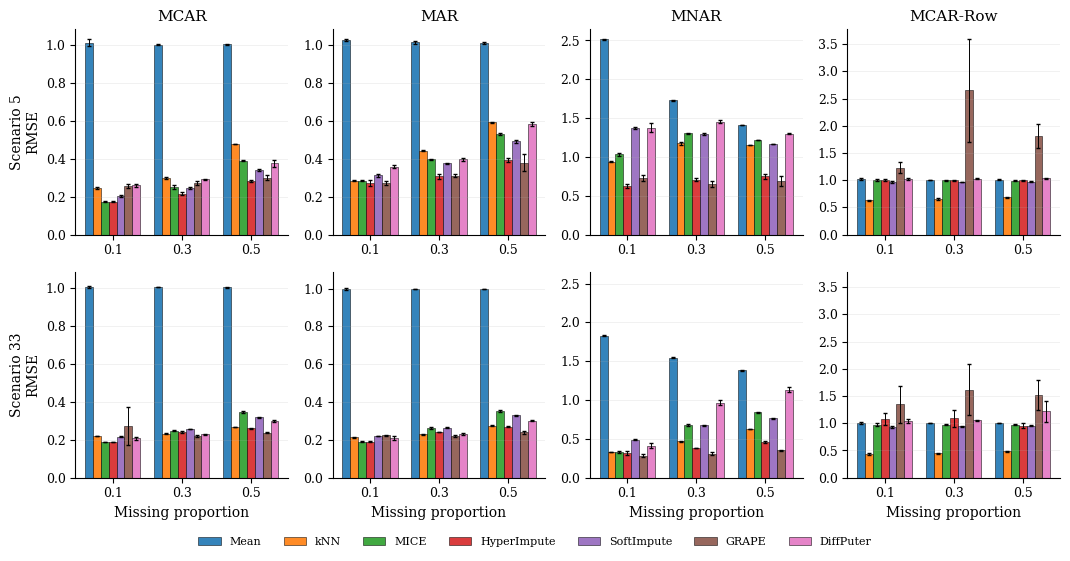

\begin{tabular}{llcccc}
\toprule
 &  & Wasserstein & Mean shift & Var.\ retention & Corr.\ Frob. \\
Dataset & Method &  &  &  &  \\
\midrule
\multirow[t]{7}{*}{Scenario 5} & Mean & 0.630 $\pm$ 0.001 & 0.036 $\pm$ 0.002 & 0.000 $\pm$ 0.000 & 5.819 $\pm$ 0.016 \\
 & kNN & 0.053 $\pm$ 0.000 & 0.030 $\pm$ 0.001 & 0.814 $\pm$ 0.003 & 0.512 $\pm$ 0.029 \\
 & MICE & 0.048 $\pm$ 0.001 & 0.008 $\pm$ 0.001 & 0.896 $\pm$ 0.009 & 0.355 $\pm$ 0.016 \\
 & HyperImpute & \textbf{0.031 $\pm$ 0.001} & 0.008 $\pm$ 0.001 & \textbf{0.945 $\pm$ 0.008} & \textbf{0.336 $\pm$ 0.017} \\
 & SoftImpute & 0.077 $\pm$ 0.001 & \textbf{0.006 $\pm$ 0.001} & 0.769 $\pm$ 0.003 & 0.556 $\pm$ 0.049 \\
 & GRAPE & 0.087 $\pm$ 0.022 & 0.053 $\pm$ 0.030 & 0.900 $\pm$ 0.013 & 0.892 $\pm$ 0.047 \\
 & DiffPuter & 0.054 $\pm$ 0.005 & 0.028 $\pm$ 0.009 & 1.070 $\pm$ 0.006 & 0.592 $\pm$ 0.020 \\
\cline{1-6}
\multirow[t]{7}{*}{Scenario 33} & Mean & 0.789 $\pm$ 0.001 & 0.027 $\pm$ 0.002 & 0.000 $\pm$ 0.000 & 10.814 $\pm$ 0.026 \\
 & 

In [20]:
from common.visualization import stat_fidelity_table_multi, plot_metric_bars_datasets
scenario5_csv = CSV_DIR / "scenario5_imputation_results.csv"
scenario33_csv = CSV_DIR / "scenario33_imputation_results.csv"

latex = stat_fidelity_table_multi(
    {"Scenario 5": scenario5_csv, "Scenario 33": scenario33_csv},
    scenario="MCAR", proportion=0.3, latex=True)


plot_metric_bars_datasets(
    {"Scenario 5": scenario5_csv, "Scenario 33": scenario33_csv},
    metric="rmse", ylabel="RMSE", filename=FIGURES_DIR / "rmse.png",)

print(latex)